# 02_DTC_With_DR

## Decision Tree Classifier With Feature-Importance-Based Dimensionality Reduction

This notebook trains a DTC using the already reduced dataset. Feature selection was completed previously using an initial Decision Tree and feature importance, so this notebook does not redo dimensionality reduction.


In [1]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_style("whitegrid")
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results directory is ready.")

from sklearn.tree import DecisionTreeClassifier


Results directory is ready.


### Load Reduced DTC Dataset and Feature Selection Artifacts

In [2]:
X_train = pd.read_csv(ROOT / "DTC" / "train" / "x_train_dtc_selected.csv")
X_test = pd.read_csv(ROOT / "DTC" / "test" / "x_test_dtc_selected.csv")
y_train = pd.read_csv(ROOT / "DTC" / "train" / "y_train.csv").squeeze()
y_test = pd.read_csv(ROOT / "DTC" / "test" / "y_test.csv").squeeze()

selected_features = pd.read_csv(ROOT / "DTC" / "selected_features.csv")
initial_importance = pd.read_csv(ROOT / "DTC" / "initial_tree_feature_importance.csv")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nSelected Features Preview:")
print(selected_features.head(20).to_string(index=False))

print("\nInitial Tree Feature Importance Preview:")
print(initial_importance.head(20).to_string(index=False))


X_train: (4930, 15)
X_test: (2113, 15)
y_train: (4930,)
y_test: (2113,)

Selected Features Preview:
              Selected Feature
                  TotalCharges
                        tenure
                MonthlyCharges
   InternetService_Fiber optic
          PaperlessBilling_Yes
                   gender_Male
                   Partner_Yes
            OnlineSecurity_Yes
PaymentMethod_Electronic check
                Dependents_Yes
               TechSupport_Yes
                 SeniorCitizen
    PaymentMethod_Mailed check
             MultipleLines_Yes
          DeviceProtection_Yes

Initial Tree Feature Importance Preview:
                         Feature  Importance
                    TotalCharges    0.218622
                          tenure    0.199839
                  MonthlyCharges    0.167968
     InternetService_Fiber optic    0.104824
            PaperlessBilling_Yes    0.029724
                     gender_Male    0.028302
                     Partner_Yes    0.023043
  

### Why Feature Selection for DTC?

Using selected important features can reduce noise and simplify the model while preserving interpretability. Decision Trees remain transparent because splits can still be explained feature-by-feature.


In [6]:
dtc = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
}
metrics_df = pd.DataFrame([metrics])
metrics_path = RESULTS_DIR / "dtc_with_dr_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("DTC With DR metrics:")
print(metrics_df.to_string(index=False))
print("\nSaved metrics CSV to results/.")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

comparison_script = ROOT / "scripts" / "update_model_comparison.py"
if comparison_script.exists():
    subprocess.run(["python", str(comparison_script)], check=False)
    print("Updated model_comparison_results.csv")


DTC With DR metrics:
 Accuracy  Precision   Recall  F1-score
 0.786559   0.613636 0.529412  0.568421

Saved metrics CSV to results/.

Confusion Matrix:
[[1365  187]
 [ 264  297]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1552
           1       0.61      0.53      0.57       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



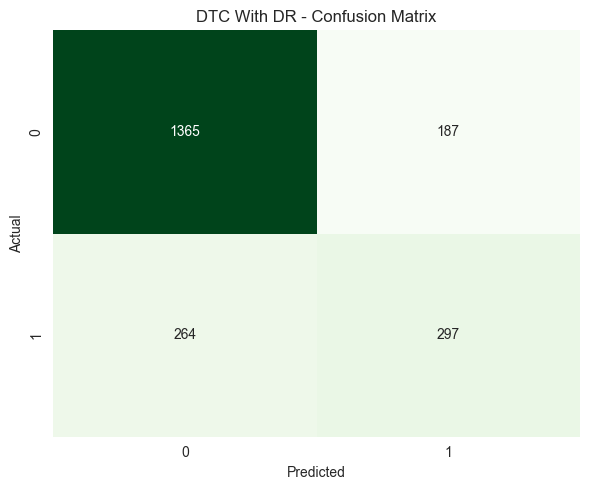

Saved confusion matrix plot to results/.


In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("DTC With DR - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
cm_path = RESULTS_DIR / "dtc_with_dr_confusion_matrix.png"
plt.tight_layout()
plt.savefig(cm_path, dpi=300)
plt.show()
print("Saved confusion matrix plot to results/.")


### Brief Comparison vs DTC Without DR

If baseline DTC results exist, the next cell compares key metrics side-by-side.


In [8]:
baseline_path = RESULTS_DIR / "dtc_without_dr_metrics.csv"
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    baseline.insert(0, "Experiment", "DTC Without DR")
    current = metrics_df.copy()
    current.insert(0, "Experiment", "DTC With DR")
    comparison = pd.concat([baseline, current], ignore_index=True)
    print(comparison.to_string(index=False))
else:
    print("Baseline DTC metrics file not found yet. Run 01_DTC_Without_DR.ipynb first for comparison.")


    Experiment  Accuracy  Precision   Recall  F1-score
DTC Without DR  0.788452   0.622318 0.516934  0.564752
   DTC With DR  0.786559   0.613636 0.529412  0.568421


In [9]:
print("\nExperiment completed successfully.")
print("Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.")
print("Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.")



Experiment completed successfully.
Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.
Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.
